In [1]:
import pandas as pd
import warnings

from dmm.config_options import Conf
from sensitivity import *
from training_configuration import SPLITS

warnings.filterwarnings("ignore")


/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/Users/fabring/dmm_env_310/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotat

In [2]:
conf = Conf(
    model = "EGFR_MAPK__logobs_tegfr_aggavg",  # base model
    data = "dream_cytof",
    n_hidden = 6,
    depth = 0,
    dropout_rate=0.1,
    l1reg_inflater_output = 1e-2,
    inflater_output_reg_epoch=200,
    inflater_bound=3,
    l2reg_inflater_output = 0,
    recon_loss=1e-4,
    n_epoch=500,
    multiheaded=False,
)

results_params_df, results_latent_df = compute_sensitivities(
    conf=conf,
    context_features=[("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")],
    splits=[split for split in SPLITS if split != "all"],
    latent_sensitivities={"cytof_init": True, "multimodal": True},
    n_jobs=10,
    multiheaded_multimodal=True,
)

results_params_df.to_csv(
    "sensitivity_analysis_params_cytof_init_multimodal_tEGFR_p38_nhidden6.csv",
    index=False
)

results_latent_df.to_csv(
    "sensitivity_analysis_latent_cytof_init_multimodal_tEGFR_p38_nhidden6.csv",
    index=False
)

context=cytof_init, split=HCC1500, job=0, params: 100%|██████████| 44/44 [00:52<00:00,  1.20s/it]
context=cytof_init, split=HCC1500, job=0, latents: 100%|██████████| 6/6 [00:04<00:00,  1.30it/s]
context=cytof_init, split=HCC1500, job=1, params: 100%|██████████| 44/44 [00:55<00:00,  1.26s/it]
context=cytof_init, split=HCC1500, job=1, latents: 100%|██████████| 6/6 [00:04<00:00,  1.36it/s]
context=cytof_init, split=HCC1500, job=2, params: 100%|██████████| 44/44 [00:54<00:00,  1.25s/it]
context=cytof_init, split=HCC1500, job=2, latents: 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]
context=cytof_init, split=HCC1500, job=3, params: 100%|██████████| 44/44 [00:53<00:00,  1.22s/it]
context=cytof_init, split=HCC1500, job=3, latents: 100%|██████████| 6/6 [00:04<00:00,  1.31it/s]
context=cytof_init, split=HCC1500, job=4, params: 100%|██████████| 44/44 [00:58<00:00,  1.32s/it]
context=cytof_init, split=HCC1500, job=4, latents: 100%|██████████| 6/6 [00:04<00:00,  1.33it/s]
context=cytof_init, split

## Reload from here directly

In [3]:
results_params_df = pd.read_csv("sensitivity_analysis_params_cytof_init_multimodal_tEGFR_p38_nhidden6.csv")
results_latent_df = pd.read_csv("sensitivity_analysis_latent_cytof_init_multimodal_tEGFR_p38_nhidden6.csv")

Index(['RPS6KA1_p_S380_ERK__Y204_p_kw', 'ERK_p_Y204_MEK__S222_p_kw',
       'TOPK_p_Y74_EGFR__Y1173_p_kw', 'ERBB2_p_Y1248_ERBB2_kw',
       'ERBB2_p_Y1248_EGFR__Y1173_p_kw', 'MEK_p_S222_ERK__Y204_p_kw',
       'ERBB2_p_Y1248_ERBB3__Y1289_p_kw', 'ERBB2_p_Y1248_serum_0_kw',
       'MEK_p_S222_ERBB2__Y1248_p_kw', 'MEK_p_S222_ERBB3__Y1289_p_kw'],
      dtype='object', name='param')


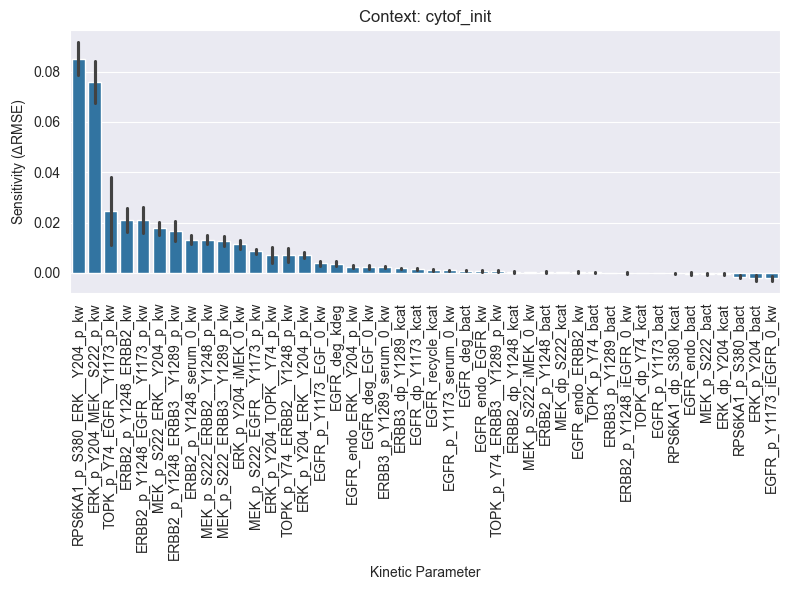

Index(['ERK_p_Y204_MEK__S222_p_kw', 'RPS6KA1_p_S380_ERK__Y204_p_kw',
       'TOPK_p_Y74_EGFR__Y1173_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw',
       'MEK_p_S222_ERK__Y204_p_kw', 'ERBB2_p_Y1248_ERBB3__Y1289_p_kw',
       'MEK_p_S222_ERBB3__Y1289_p_kw', 'ERK_p_Y204_iMEK_0_kw',
       'ERK_p_Y204_TOPK__Y74_p_kw', 'ERBB2_p_Y1248_ERBB2_kw'],
      dtype='object', name='param')


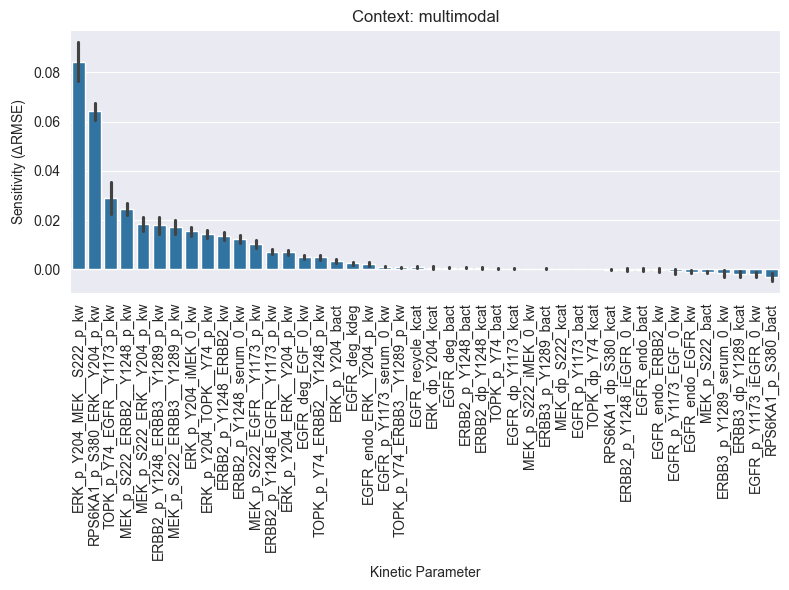

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns


for context, _ in [("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")]:
    # filter to multimodal context
    df = results_params_df[(results_params_df.context == context)]

    # compute mean rmse_diff per param
    order = (
        df.groupby("param")["rmse_diff_zeroed"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    print(order[:10])

    plt.figure(figsize=(8, 6))
    # plot with that order
    sns.barplot(
        data=df,
        x="param",
        y="rmse_diff_zeroed",
        order=order,
        errorbar='se'
    )

    plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
    plt.xlabel("Kinetic Parameter")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()

Index(['ERK_p_Y204_iMEK_0_kw', 'ERBB2_p_Y1248_iEGFR_0_kw',
       'ERBB2_p_Y1248_EGFR__Y1173_p_kw', 'MEK_p_S222_ERK__Y204_p_kw',
       'EGFR_p_Y1173_iEGFR_0_kw', 'ERK_p_Y204_TOPK__Y74_p_kw',
       'EGFR_p_Y1173_serum_0_kw', 'EGFR_p_Y1173_EGF_0_kw',
       'MEK_p_S222_EGFR__Y1173_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw'],
      dtype='object', name='param')


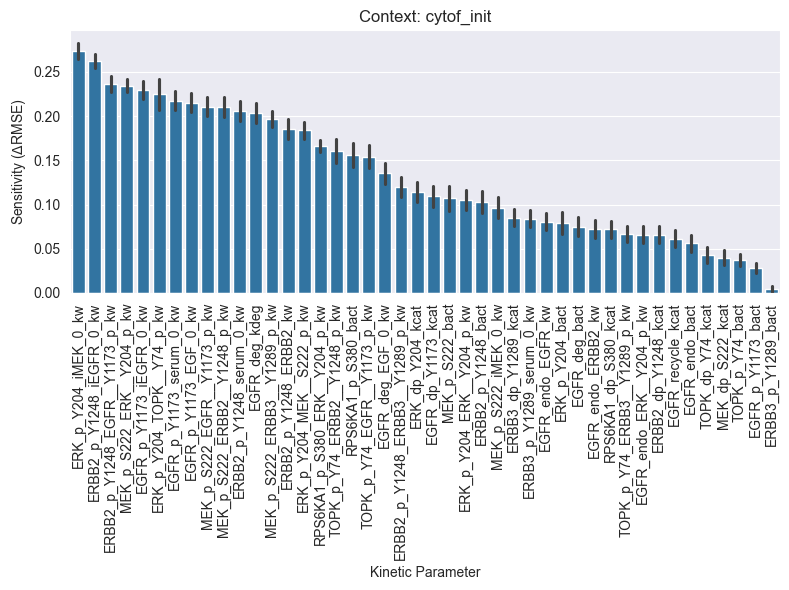

Index(['ERK_p_Y204_iMEK_0_kw', 'ERBB2_p_Y1248_iEGFR_0_kw',
       'MEK_p_S222_ERK__Y204_p_kw', 'EGFR_p_Y1173_iEGFR_0_kw',
       'EGFR_p_Y1173_EGF_0_kw', 'ERBB2_p_Y1248_EGFR__Y1173_p_kw',
       'EGFR_p_Y1173_serum_0_kw', 'EGFR_deg_kdeg',
       'MEK_p_S222_EGFR__Y1173_p_kw', 'MEK_p_S222_ERBB2__Y1248_p_kw'],
      dtype='object', name='param')


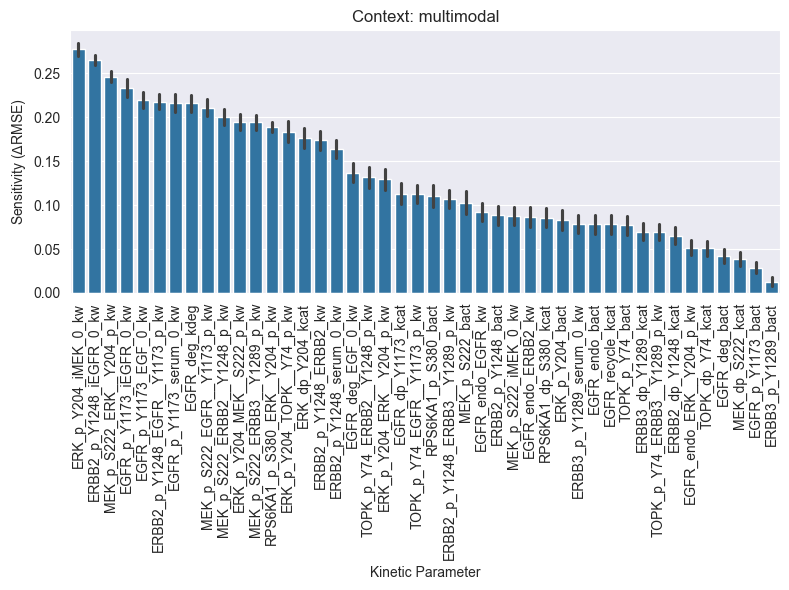

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


for context, _ in [("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")]:
    # filter to multimodal context
    df = results_params_df[(results_params_df.context == context)]

    # compute mean rmse_diff per param
    order = (
        df.groupby("param")["rmse_diff_activated"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    print(order[:10])

    plt.figure(figsize=(8, 6))
    # plot with that order
    sns.barplot(
        data=df,
        x="param",
        y="rmse_diff_activated",
        order=order,
        errorbar='se'
    )

    plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
    plt.xlabel("Kinetic Parameter")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()

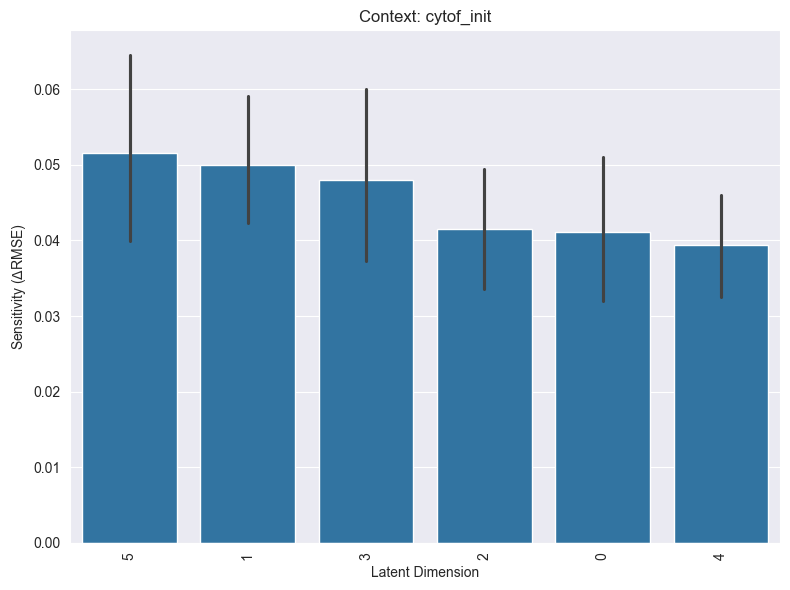

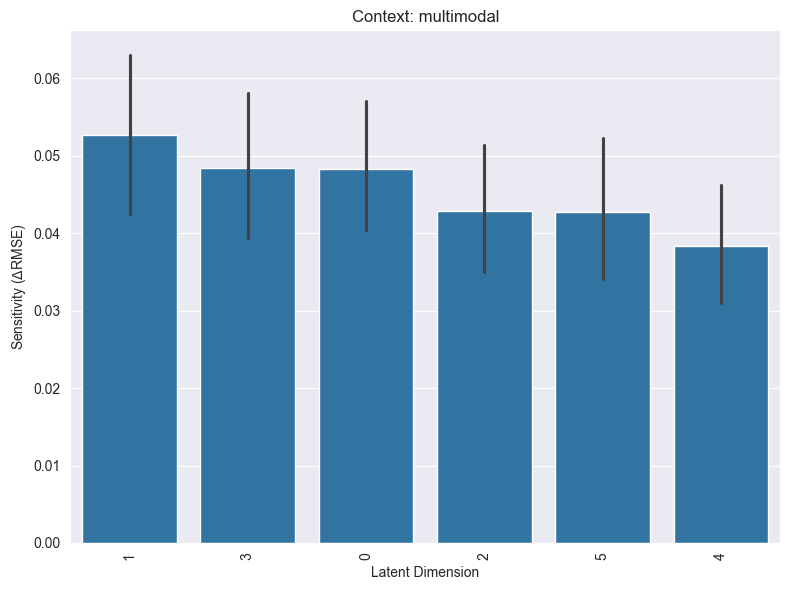

In [48]:
for context, _ in [("cytof_init", "RFE_15_permute"), ("multimodal", "RFE_10_permute")]:
    # filter to multimodal context
    df = results_latent_df[(results_latent_df.context == context)]

    # compute mean rmse_diff per param
    order = (
        df.groupby("latent_dimension")["rmse_diff"]
          .mean()
          .sort_values(ascending=False)
          .index
    )

    plt.figure(figsize=(8, 6))
    # plot with that order
    sns.barplot(
        data=df,
        x="latent_dimension",
        y="rmse_diff",
        order=order,
        # errorbar="sd",
        # hue="samples"
    )

    plt.ylabel(r"Sensitivity ($\Delta$RMSE)")
    plt.xlabel("Latent Dimension")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()

    plt.show()

<Axes: >

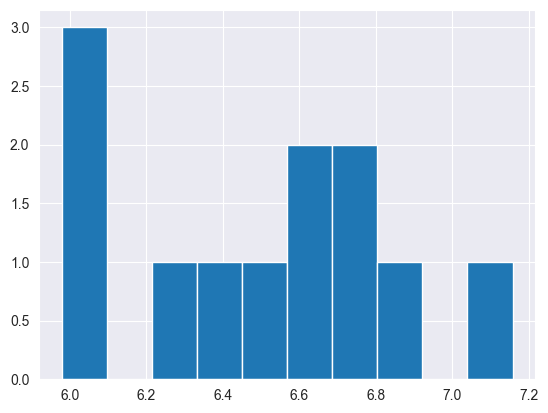

In [31]:
rank_summary.mean_rank.hist()

In [38]:
df_avg

,context,samples,job,latent_dimension,avg_rmse_diff,rank
0,cytof_init,BT20,0,0,0.056221,2.0
1,cytof_init,BT20,0,1,0.017203,4.0
2,cytof_init,BT20,0,2,0.035018,3.0
3,cytof_init,BT20,0,3,0.066300,1.0
4,cytof_init,BT20,0,4,0.017163,5.0
...,...,...,...,...,...,...
835,multimodal,UACC893,9,1,0.034968,2.0
836,multimodal,UACC893,9,2,0.012663,6.0
837,multimodal,UACC893,9,3,0.026831,5.0
838,multimodal,UACC893,9,4,0.027144,4.0


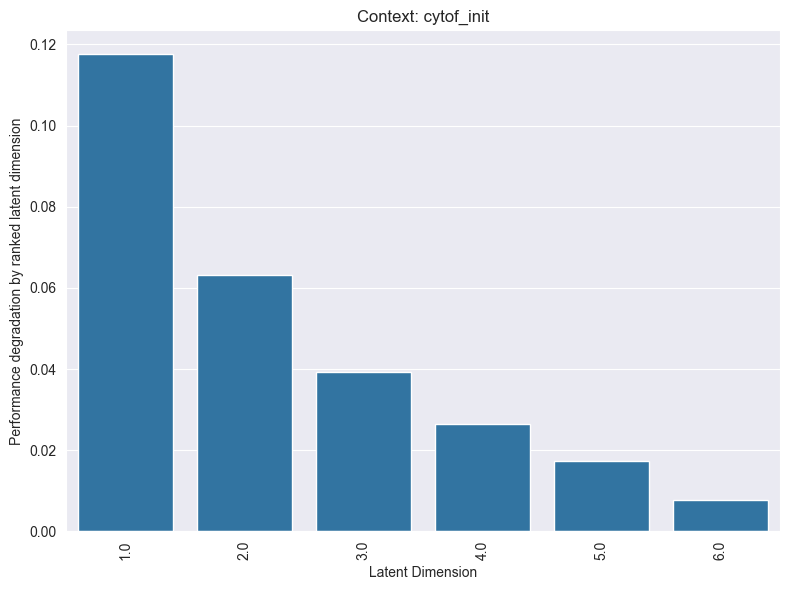

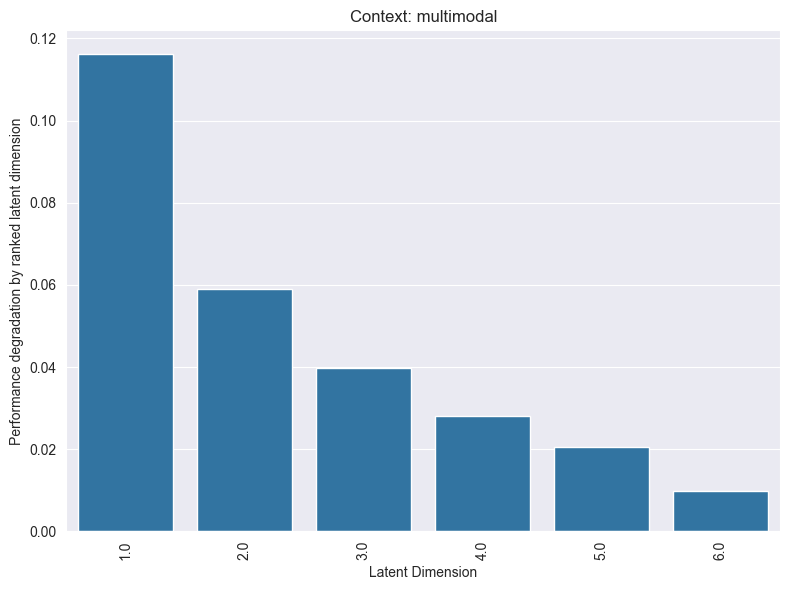

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Rank latent dimensions within each (context, samples, job) combo
df = results_latent_df.copy()

# Collapse train/val (or any dataset-level distinction)
df_avg = (
    results_latent_df
    .groupby(["context", "samples", "job", "latent_dimension"], as_index=False)
    .agg(avg_rmse_diff=("rmse_diff", "mean"))
)

df_avg["rank"] = (
    df_avg
    .groupby(["context", "samples", "job"])["avg_rmse_diff"]
    .rank(method="average", ascending=False)  # 1 = highest (most sensitive)
)

# 2) Aggregate across samples and jobs for each (context, latent_dimension)
rank_summary = (
    df_avg
    .groupby(["context", "rank"])["avg_rmse_diff"]
    .mean()
    .reset_index()
    .rename(columns={"avg_rmse_diff": "agg_rmse_diff"})
)


# 3) Plot per context
for context in ["cytof_init", "multimodal"]:
    ctx_df = rank_summary[rank_summary["context"] == context].copy()

    # sort so best (lowest mean_rank) appears first
    ctx_df = ctx_df.sort_values("agg_rmse_diff", ascending=False)
    order = ctx_df["rank"]

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=ctx_df,
        x="rank",
        y="agg_rmse_diff",
        order=order
    )

    plt.ylabel("Performance degradation by ranked latent dimension")
    plt.xlabel("Latent Dimension")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

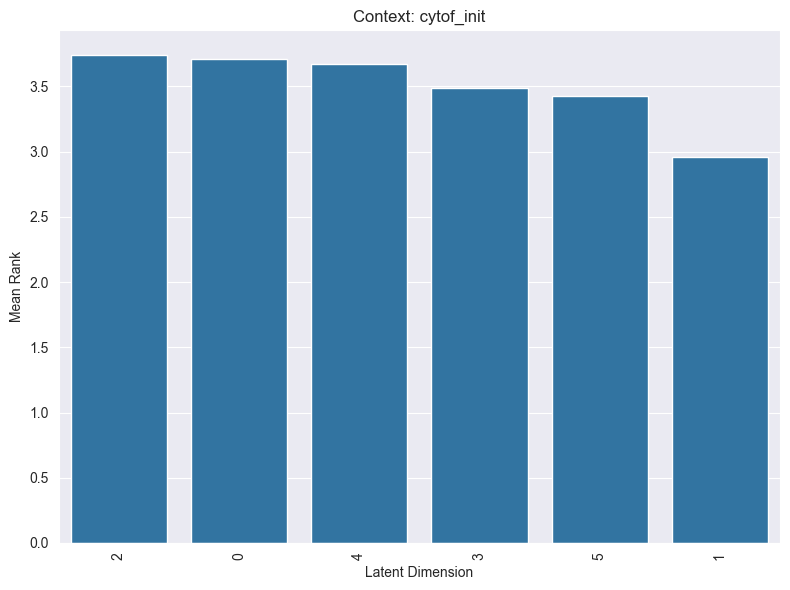

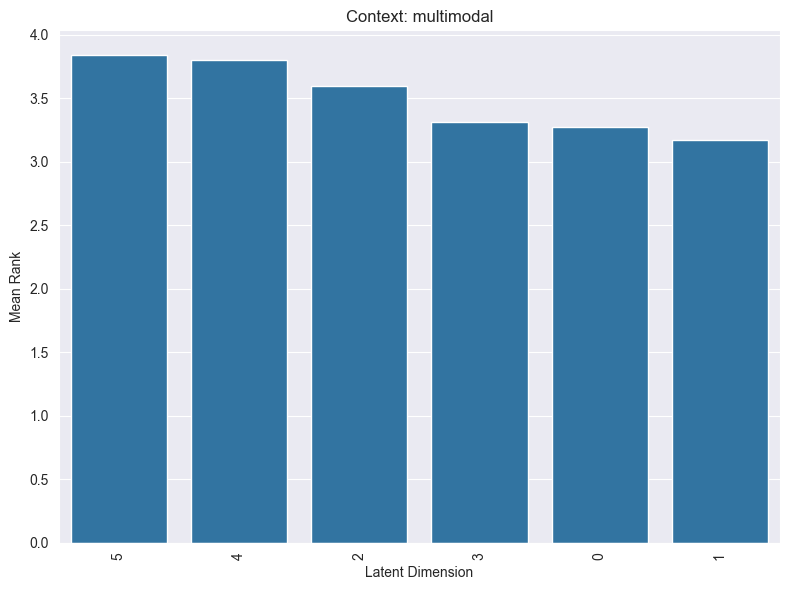

In [47]:
# 1) Rank latent dimensions within each (context, samples, job) combo
df = results_latent_df.copy()

# Collapse train/val (or any dataset-level distinction)
df_avg = (
    results_latent_df
    .groupby(["context", "samples", "job", "latent_dimension"], as_index=False)
    .agg(avg_rmse_diff=("rmse_diff", "mean"))
)

df_avg["rank"] = (
    df_avg
    .groupby(["context", "samples", "job"])["avg_rmse_diff"]
    .rank(method="average", ascending=False)  # 1 = highest (most sensitive)
)

# 2) Aggregate across samples and jobs for each (context, latent_dimension)
rank_summary = (
    df_avg
    .groupby(["context", "latent_dimension"])["rank"]
    .mean()
    .reset_index()
    .rename(columns={"rank": "mean_rank"})
)


# 3) Plot per context
for context in ["cytof_init", "multimodal"]:
    ctx_df = rank_summary[rank_summary["context"] == context].copy()

    # sort so best (lowest mean_rank) appears first
    ctx_df = ctx_df.sort_values("mean_rank", ascending=False)
    order = ctx_df["latent_dimension"]

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=ctx_df,
        x="latent_dimension",
        y="mean_rank",
        order=order
    )

    plt.ylabel("Mean Rank")
    plt.xlabel("Latent Dimension")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

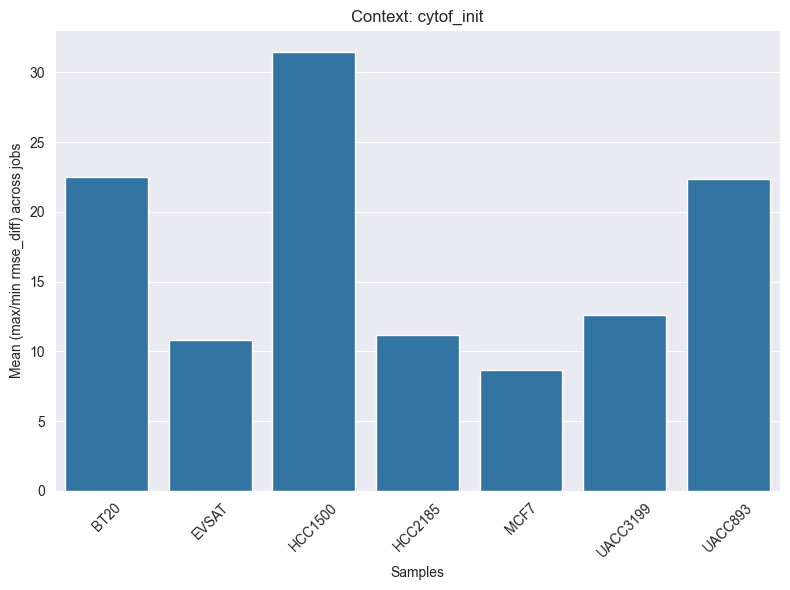

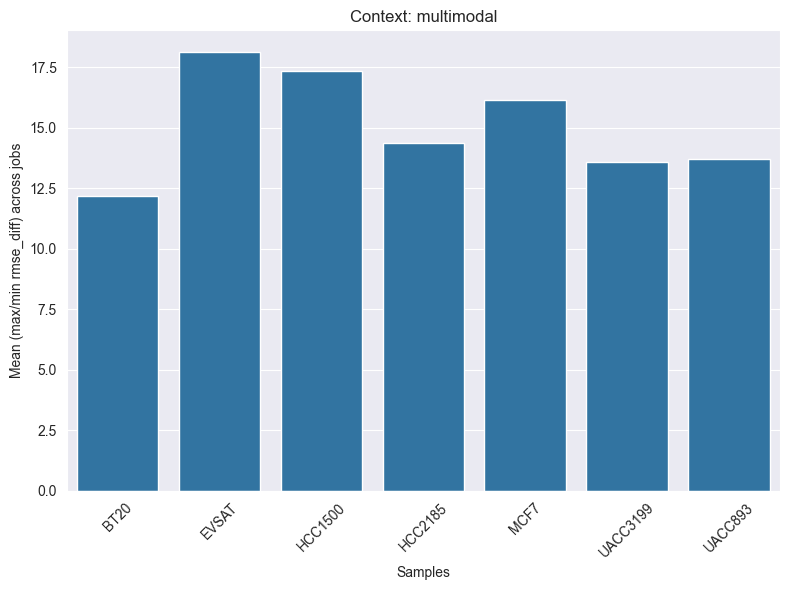

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------
# 1. Average rmse_diff across dataset (train/val)
# -----------------------------------

df_avg = (
    results_latent_df
    .groupby(["context", "samples", "job", "latent_dimension"], as_index=False)
    .agg(avg_rmse_diff=("rmse_diff", "mean"))
)

# -----------------------------------
# 2. Compute absolute ratio max/min rmse_diff per (context, samples, job)
# -----------------------------------

ratio_df = (
    df_avg
    .groupby(["context", "samples", "job"])
    .agg(
        max_rmse=("avg_rmse_diff", "max"),
        min_rmse=("avg_rmse_diff", "min")
    )
    .reset_index()
)

# avoid division by zero
ratio_df = ratio_df[ratio_df.min_rmse != 0].copy()
ratio_df["abs_ratio"] = np.abs(ratio_df["max_rmse"] / ratio_df["min_rmse"])

# -----------------------------------
# 3. Aggregate across jobs for each (context, samples)
# -----------------------------------

ratio_summary = (
    ratio_df
    .groupby(["context", "samples"])
    .agg(
        mean_ratio=("abs_ratio", "mean"),
        sd_ratio=("abs_ratio", "std"),
        n_jobs=("abs_ratio", "count")
    )
    .reset_index()
)

# -----------------------------------
# 4. Plot per context: ratio vs samples
# -----------------------------------

for context in ratio_summary.context.unique():
    ctx = ratio_summary[ratio_summary.context == context]

    plt.figure(figsize=(8, 6))
    sns.barplot(
        data=ctx,
        x="samples",
        y="mean_ratio",
        errorbar=None
    )

    plt.ylabel("Mean (max/min rmse_diff) across jobs")
    plt.xlabel("Samples")
    plt.title(f"Context: {context}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [56]:
ratio_summary.groupby("context")["mean_ratio"].mean()

context
cytof_init    17.089253
multimodal    15.075622
Name: mean_ratio, dtype: float64